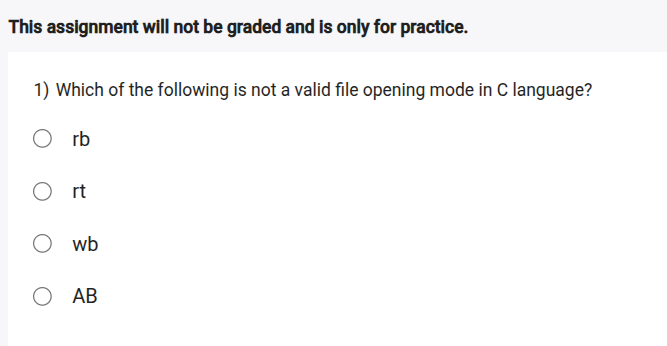

- rb -> means `read byte`
- rt -> means `read text`
- wb -> means `write byte`
- wt -> means `write text`
- ab -> means `append byte`
- at -> means `append text`
- AB -> this is wrong, should be lowercase and b
- r+ -> means `read and write`
- rb+ -> means `read and write byte`
- rt+ -> means `read and write text`
- w+ -> means `write and read` (overwrites existing file or creates new file)
- wb+ -> means `write and read byte` (overwrites existing file or creates new file)
- wt+ -> means `write and read text` (overwrites existing file or creates new file)
- ab+ -> means `append and read byte`
- at+ -> means `append and read text`

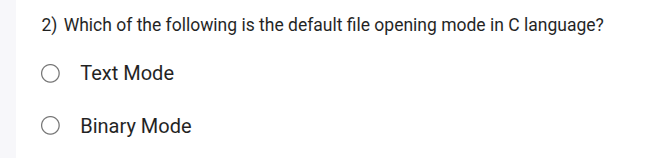

- Text Mode

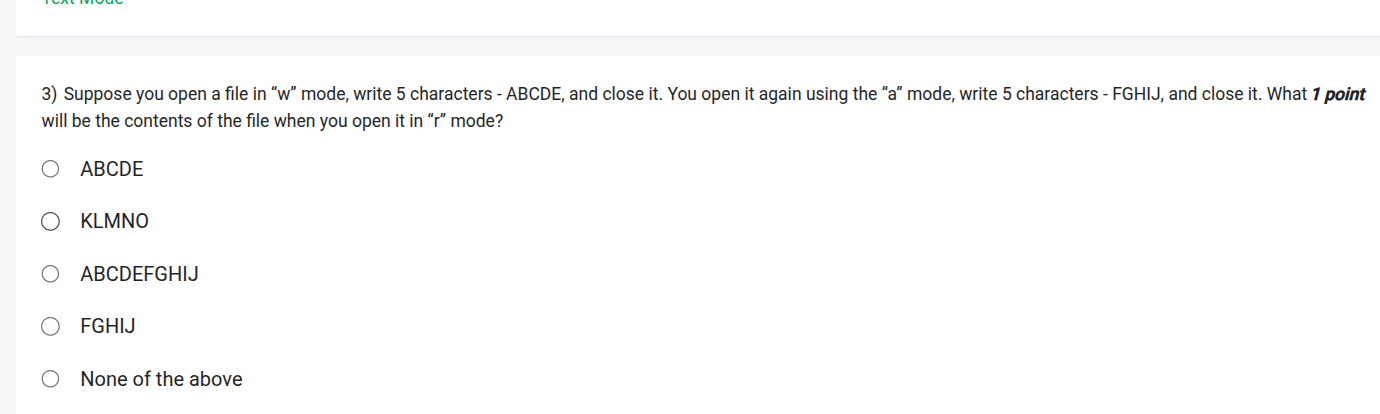

- ABCDEFGHIJ

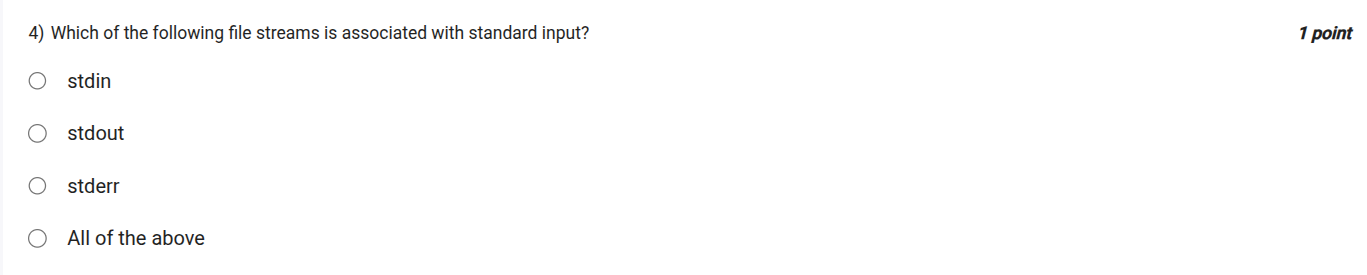

- stdin

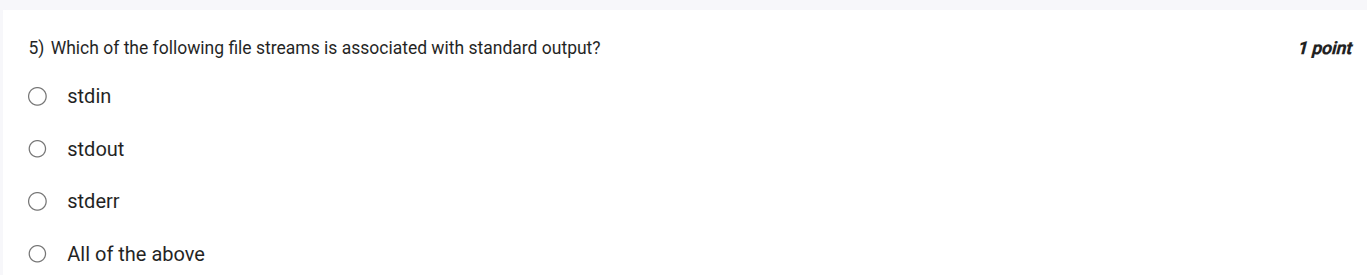

- stdout

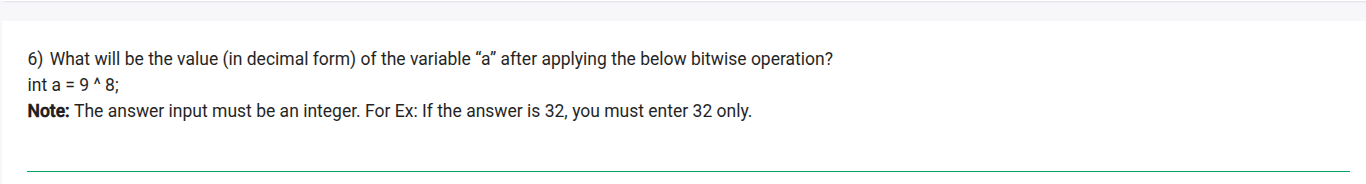

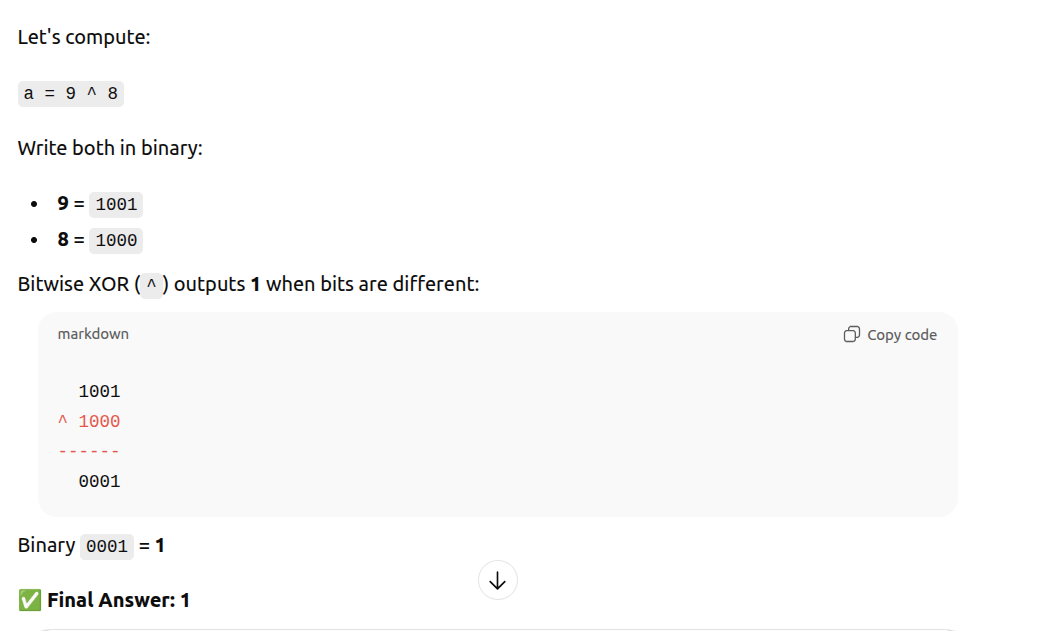

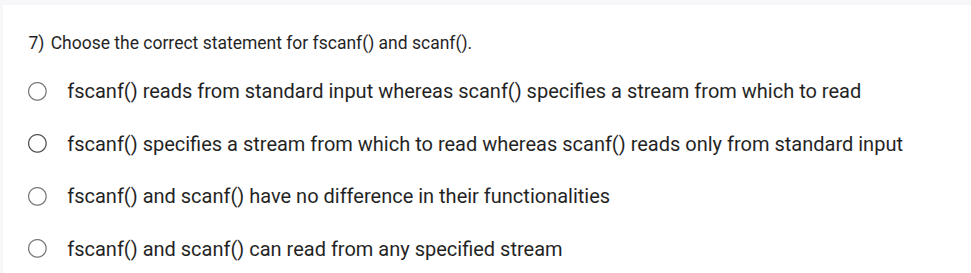

- option b, fscanf() reads from a stream, scanf() reads from stdin


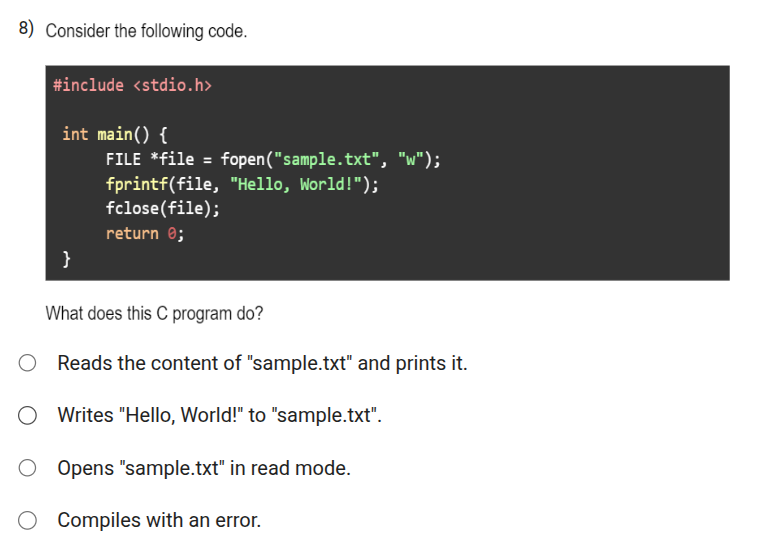

option b

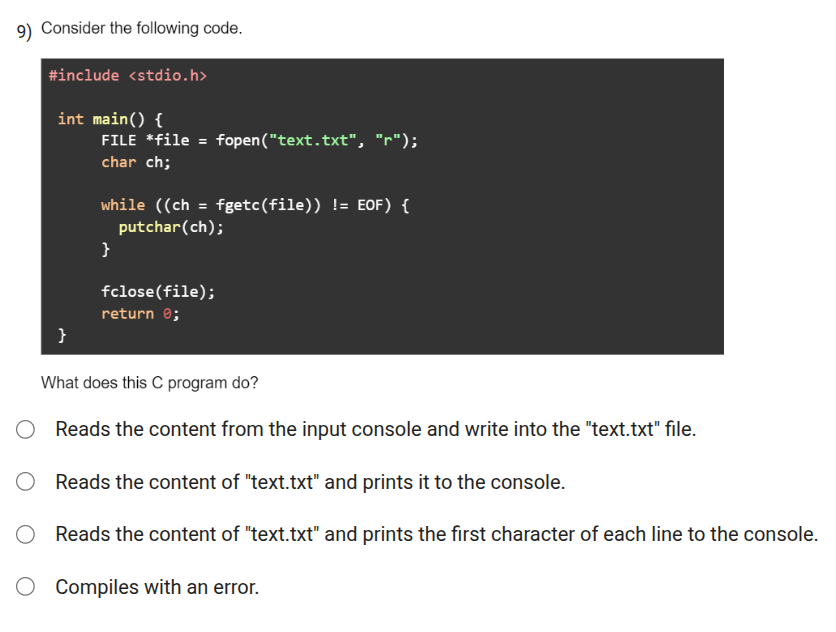

- putchar(ch) writes the character ch to stdout and returns the same character on success. On failure, it returns EOF.
- getchar() reads the next character from stdin and returns it as an unsigned char cast to an int. On failure, it returns EOF.
- b) in this code, it it reads the content of text.txt and prints it to the console

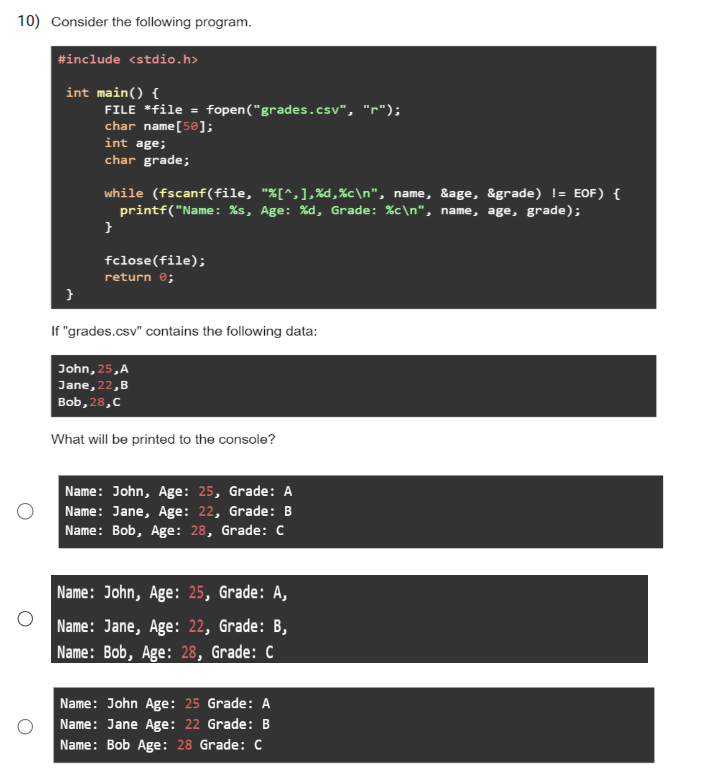

- option a

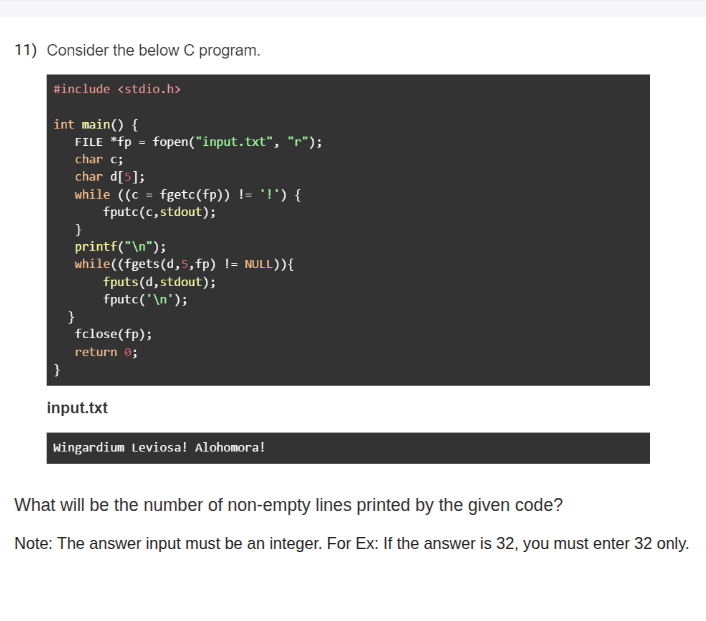

 - fgetc(fp) - means read a character from the file pointed by fp
 - fputc(ch, fp) - means write the character ch to the file pointed by fp
 - fputc(c,stdout) writes the character c to the standard output (console)
 - fgets(buffer, size, fp) reads a string from the file pointed by fp and stores it in buffer, up to size-1 characters or until a newline is encountered
 - fputs(str,stdout) writes the string str to the standard output (console)

The user wants to know the number of **non-empty lines** printed by the given C program when executed with the provided `input.txt` file.

## 💻 C Program Analysis

The program reads from `input.txt` and prints content to the standard output (`stdout`).

### 1\. File Content (`input.txt`)

The content of `input.txt` is a single line:

```
Wingardium Leviosa! Alohomora!
```

### 2\. First `while` Loop (Character-by-Character Reading)

```c
FILE *fp = fopen("input.txt", "r");
char c;
// ...
while ((c = fgetc(fp)) != '!') {
    fputc(c, stdout);
}
printf("\n");
```

  * `fgetc(fp)` reads characters one by one from the file pointer `fp`.
  * The loop continues as long as the character read is **not** `'!'`.
  * Inside the loop, `fputc(c, stdout)` prints the character to the console.

| Character Read (`c`) | Condition (`c != '!'`) | Action (`fputc(c, stdout)`) | Output so far | File Pointer Position (After read) |
| :---: | :---: | :--- | :--- | :--- |
| W | True | Print 'W' | W | 1 |
| i | True | Print 'i' | Wi | 2 |
| n | True | Print 'n' | Win | 3 |
| g | True | Print 'g' | Wing | 4 |
| a | True | Print 'a' | Winga | 5 |
| r | True | Print 'r' | Wingar | 6 |
| d | True | Print 'd' | Wingard | 7 |
| i | True | Print 'i' | Wingardi | 8 |
| u | True | Print 'u' | Wingardiu | 9 |
| m | True | Print 'm' | Wingardium | 10 |
| (space) | True | Print ' ' | Wingardium | 11 |
| L | True | Print 'L' | Wingardium L | 12 |
| e | True | Print 'e' | Wingardium Le | 13 |
| v | True | Print 'v' | Wingardium Lev | 14 |
| i | True | Print 'i' | Wingardium Levi | 15 |
| o | True | Print 'o' | Wingardium Levio | 16 |
| s | True | Print 's' | Wingardium Levios | 17 |
| a | True | Print 'a' | Wingardium Leviosa | 18 |
| **\!** | **False** | (Loop terminates) | - | 19 |

  * **Line 1 Output:** `Wingardium Leviosa`
  * After the loop, `printf("\n");` prints a **newline character**.
  * **Total Non-Empty Lines Printed so far: 1**

### 3\. Second `while` Loop (String/Line Reading)

```c
char d[5]; // Stores up to 4 chars + null terminator
// ...
while ((fgets(d, 5, fp)) != NULL) {
    fputs(d, stdout);
    fputc('\n', stdout);
}
```

  * `fgets(d, 5, fp)` reads at most $5-1 = 4$ characters from the file into the buffer `d`, or until a newline or EOF is encountered. Since the input file is a single line without a visible newline at the end, it will primarily read 4 characters at a time until the end of the file.
  * The file pointer is currently at position 19, right after the first `'!'`.
  * The remaining content in `input.txt` is: `  Alohomora! ` (12 characters + EOF).

**Iteration 1:**

  * `fgets(d, 5, fp)` reads 4 characters: `  Alo ` (The space before Alohomora and the first three letters).
  * `fgets` returns the pointer `d` (which is not `NULL`).
  * `fputs(d, stdout)` prints: `  Alo `
  * `fputc('\n', stdout)` prints a newline.
  * **Line 2 Output:** `  Alo ` (This is a non-empty line because of the leading space and the letters).

**Iteration 2:**

  * `fgets(d, 5, fp)` reads 4 characters: `homo`.
  * `fgets` returns the pointer `d`.
  * `fputs(d, stdout)` prints: `homo`
  * `fputc('\n', stdout)` prints a newline.
  * **Line 3 Output:** `homo`

**Iteration 3:**

  * `fgets(d, 5, fp)` reads the remaining 4 characters: `ra!\n` (The characters `ra!`, and since it's the end of the file, the EOF is encountered). The content of the file is `Wingardium Leviosa! Alohomora!` followed by a **newline character** at the very end (though not explicitly shown, standard text files often end with one, and even if not, the EOF is hit). Let's assume the remaining characters are `ra!` followed by the implicit newline/EOF. Based on the file content: `...sa!| Alohomora!|EOF`.
      * **File Position After Iteration 2:** After `homo`. Remaining content: `ra!$newline$`.
      * `fgets(d, 5, fp)` reads 4 characters: `ra!`. It hits EOF after `!`.
  * `fputs(d, stdout)` prints: `ra!`
  * `fputc('\n', stdout)` prints a newline.
  * **Line 4 Output:** `ra!`

**Iteration 4:**

  * `fgets(d, 5, fp)` is called. The file pointer is at EOF.
  * `fgets` returns **NULL**.
  * The loop terminates.

### 4\. Final Count

The lines printed to standard output are:

1.  `Wingardium Leviosa` (Non-empty)
2.  `  Alo ` (Non-empty, leading space)
3.  `homo` (Non-empty)
4.  `ra!` (Non-empty)

All four printed lines contain characters (text or space) before the final newline, making them **non-empty**.

-----

## ✅ Answer

The number of non-empty lines printed by the given code is **4**.

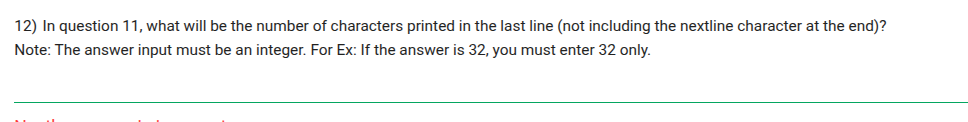

- 3

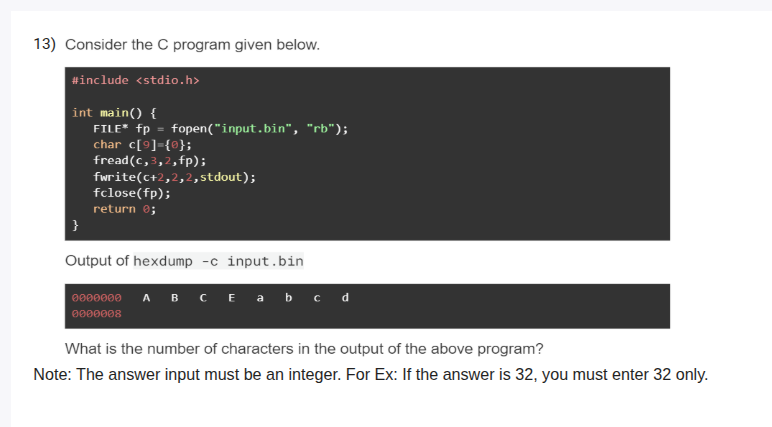

# Doubt


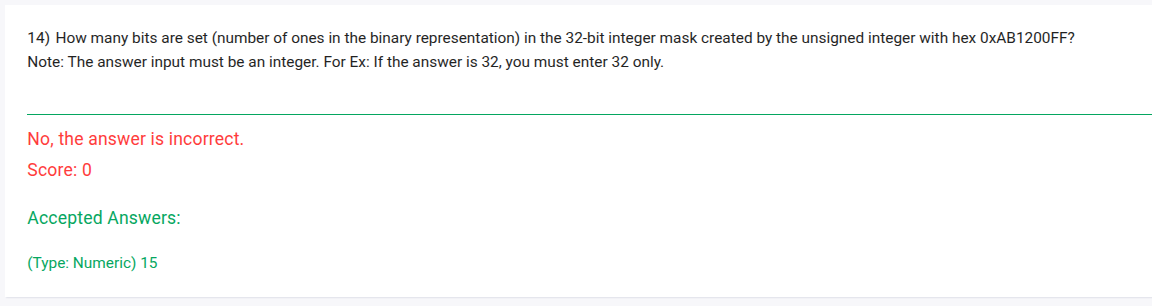

```python?code_reference&code_event_index=2
# The hexadecimal number
hex_num = "0xAB1200FF"

# Convert hex to integer
int_num = int(hex_num, 16)

# Convert integer to binary string and count the number of '1's
# bin() adds '0b' prefix, so we count in the rest of the string
binary_str = bin(int_num)
set_bits = binary_str.count('1')

print(set_bits)

```

```text?code_stdout&code_event_index=2
15

```

The number of set bits (ones in the binary representation) in the 32-bit integer mask created by `0xAB1200FF` is **15**.

-----

### Step-by-step Calculation:

1.  **Convert Hexadecimal to Binary:**
    The 32-bit hexadecimal mask `0xAB1200FF` is converted by mapping each hex digit to its 4-bit binary equivalent:

    | Hex Digit | Binary Equivalent | Number of Set Bits (ones) |
    | :-------: | :---------------: | :-----------------------: |
    | A         | $\text{1010}$      | 2                         |
    | B         | $\text{1011}$      | 3                         |
    | 1         | $\text{0001}$      | 1                         |
    | 2         | $\text{0010}$      | 1                         |
    | 0         | $\text{0000}$      | 0                         |
    | 0         | $\text{0000}$      | 0                         |
    | F         | $\text{1111}$      | 4                         |
    | F         | $\text{1111}$      | 4                         |

2.  **Count the Set Bits:**
    Summing the number of ones from each 4-bit group:
    $$2 + 3 + 1 + 1 + 0 + 0 + 4 + 4 = \mathbf{15}$$

The full 32-bit binary representation is:
$$\underbrace{1010}_{\text{A}}\ \underbrace{1011}_{\text{B}}\ \underbrace{0001}_{1}\ \underbrace{0010}_{2}\ \underbrace{0000}_{0}\ \underbrace{0000}_{0}\ \underbrace{1111}_{\text{F}}\ \underbrace{1111}_{\text{F}}$$

15

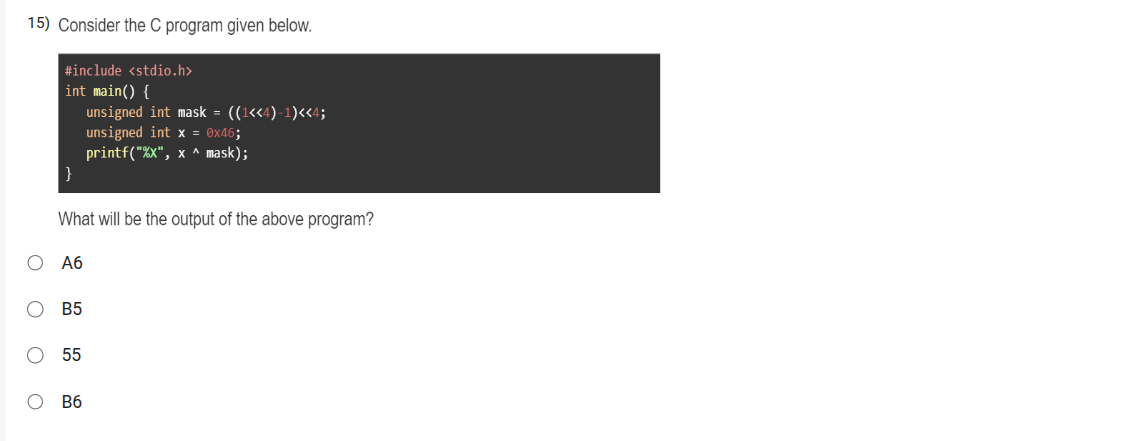

The output of the above program will be **B6**.

The correct option is **B6**.

-----

## 🔍 Step-by-Step Analysis

The program calculates a **mask** using bitwise operations and then applies that mask to the variable **x** using the bitwise **XOR** operator (`^`). The result is printed in hexadecimal format.

### 1\. Calculate the Mask

The expression for the `mask` is:

```c
unsigned int mask = (((1 << 4) - 1) << 4);
```

#### A. Inner Shift: `(1 << 4)`

This shifts the binary value $\text{1}$ four positions to the left:
$$\text{Binary 1} = \ldots 00000001$$
$$\text{Binary (1 << 4)} = \ldots 00010000 \quad \text{(Decimal 16)}$$

#### B. Subtraction: `((1 << 4) - 1)`

Subtracting 1 from $16$ (which is $15$) results in a bit pattern where the four least significant bits are set to 1.
$$\text{Binary 16} = \ldots 00010000$$
$$\text{Binary 15} = \ldots 00001111 \quad \text{(Hex 0xF)}$$

#### C. Outer Shift: `( ... ) << 4`

The result $\text{0xF}$ (or $\text{00001111}$) is then shifted four positions to the left:
$$\text{Binary 00001111}$$
$$\text{Binary mask} = \text{000011110000}$$

In hexadecimal, this is:
$$\text{mask} = \mathbf{0\text{xF0}}$$

### 2\. Define the Variable `x`

The variable `x` is initialized with the hexadecimal value:

```c
unsigned int x = 0x46;
```

In 8-bit binary representation:
$$\text{x} = \mathbf{01000110}$$

### 3\. Apply Bitwise XOR (`^`)

The program calculates $\text{x} \wedge \text{mask}$ and prints the result. The XOR operation ($\wedge$) sets the output bit to 1 if the input bits are **different**, and 0 if they are the same.

$$\text{Binary x} \quad\quad = \quad 0100 \ 0110 \quad (\text{0x46})$$
$$\text{Binary mask} = \quad 1111 \ 0000 \quad (\text{0xF0})$$
$$\text{Result} \quad\quad = \quad \overline{1011 \ 0110}$$

| $\text{x}$ (0x46) | 0 | 1 | 0 | 0 | 0 | 1 | 1 | 0 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $\text{mask}$ (0xF0) | 1 | 1 | 1 | 1 | 0 | 0 | 0 | 0 |
| **XOR ($\wedge$)** | **1** | **0** | **1** | **1** | **0** | **1** | **1** | **0** |

### 4\. Convert Result to Hexadecimal

The resulting binary value $\text{10110110}$ is converted back to hexadecimal:

$$\underbrace{1011}_{\text{B}}\ \underbrace{0110}_{6}$$

$$\text{Result} = \mathbf{0\text{xB6}}$$

The `printf("%x", ...)` function prints the output in lowercase hexadecimal, so the output is **b6**. Since the options use uppercase letters, we select **B6**.